### Adding gaussian noise to the satGEM 

In [1]:
from parcels import FieldSet, JITParticle, ParticleSet, Variable, ScipyParticle 
from parcels import AdvectionRK4

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import zarr
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl
import gsw
import math

In [4]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func
from functions import DeleteErrorParticle, SampleTS, SampleUV, StuckParticles

In [6]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [5]:
savepath = os.path.join(workingdir, 'figures')

In [7]:
### load ADT field
ssh_insitu = xr.open_dataset('data/cmems_adt_MR.nc')

In [9]:
### load SatGEM on density
satgem_SEIR_on_d = xr.open_dataset('data/satgem_SEIR_on_d.nc')

In [10]:
latmin, latmax = -62, -48
dmin, dmax = 27.0, 27.6

satgem_sel = satgem_SEIR_on_d.sel(density = slice(dmin, dmax), latitude= slice(latmin, latmax))

In [11]:
# Method 1: gaussian noise with a fixed std
mean = 0 
std = 0.01
noise_4d = np.random.normal(mean, std, satgem_sel.vgw.shape) 

In [12]:
# Method 2: gaussian noise scaled by the velocity amplitude (noise increases with velocity amplitude)
mean = 0
pc = 5

scaling_u = (pc/100)*abs(satgem_sel.ugw)
noise_u = np.random.normal(mean, scale = scaling_u)

scaling_v = (pc/100)*abs(satgem_sel.vgw)
noise_v = np.random.normal(mean, scale = scaling_v)

noise_u = xr.DataArray(noise_u, dims = satgem_sel.ugw.dims, coords = satgem_sel.ugw.coords)
noise_v = xr.DataArray(noise_v, dims = satgem_sel.vgw.dims, coords = satgem_sel.vgw.coords)

In [13]:
t = '2018-11-20'

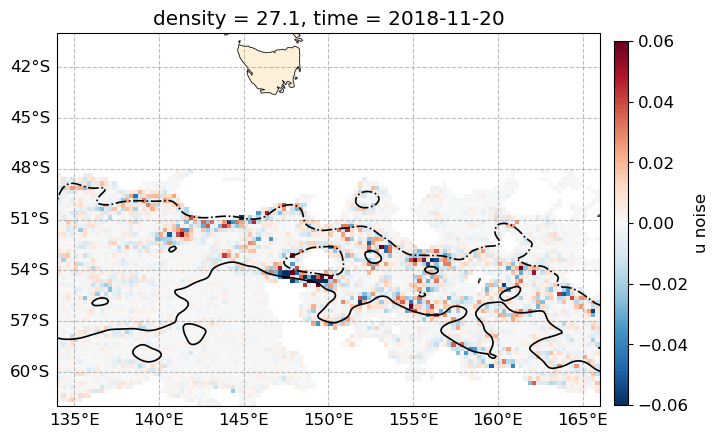

In [15]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im = noise_u.sel(density = 27.1, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                  vmin = -0.06, vmax = 0.06, 
                                                                  transform=ccrs.PlateCarree(), 
                                                                  add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('u noise')

In [104]:
lt, ln = -54, 145.5

In [156]:
# smooth the noise using a rolling filter
smooth_noise_u = noise_u.rolling(density = 3, center = True).mean().interpolate_na(dim = 'density',  fill_value="extrapolate")
smooth_noise_v = noise_v.rolling(density = 3, center = True).mean().interpolate_na(dim = 'density',  fill_value="extrapolate")

Text(0.5, 0.93, 'time = 2018-11-20, lat = -54, lon = 145.5')

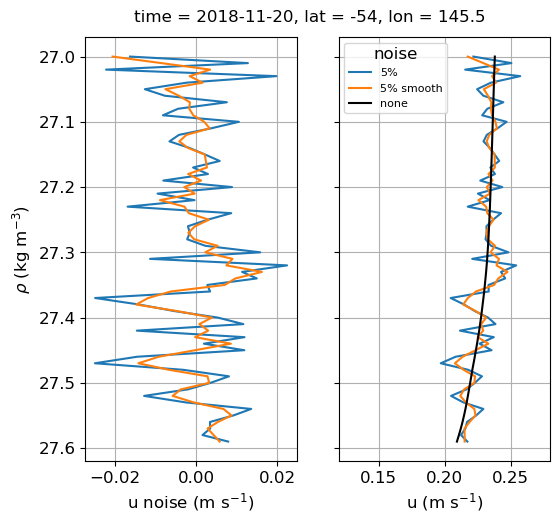

In [157]:
# velocity noise
noise_sel = noise_u.sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
noise_sel_smooth = smooth_noise_u.sel(time = t, latitude = lt, longitude = ln, method= 'nearest')

fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (6, 5.5))
noise_sel.plot(ax = ax1, y = 'density')
noise_sel_smooth.plot(ax = ax1, y = 'density')
ax1.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
ax1.set_xlabel('u noise (m s$^{-1}$)')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('')

# velocity signal with and without noise
u_no_noise = satgem_sel.ugw.sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
u_sel = (satgem_sel.ugw + noise_sel).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
u_sel_smooth = (satgem_sel.ugw + noise_sel_smooth).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')

u_sel.plot(ax = ax2, y = 'density')
u_sel_smooth.plot(ax = ax2, y = 'density')
u_no_noise.plot(ax = ax2, y = 'density', c = 'k')
ax2.set_xlabel('u (m s$^{-1}$)')
ax2.set_xlim(0.12, 0.28)
ax2.legend(['5%', '5% smooth', 'none'], title = 'noise', prop={'size': 8}, loc = 'upper left')
ax2.set_ylabel('')
ax2.grid()
ax2.set_title('')

plt.suptitle(f'time = {t}, lat = {lt}, lon = {ln}', fontsize = 12, y = 0.93)

In [113]:
# name = f'SEIR_noise_profile_{pc}noise_smoothed.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [158]:
### add noise with a specific decorreltion length scale
decorrelation_density_scale = 0.25
std_dev_profile = np.exp(-(satgem_sel.density - satgem_sel.density[0])/decorrelation_density_scale)

Text(0.5, 0.95, 'exponential decay: decorrelation scale = 0.25 \n time = 2018-11-20, lat = -54, lon = 145.5')

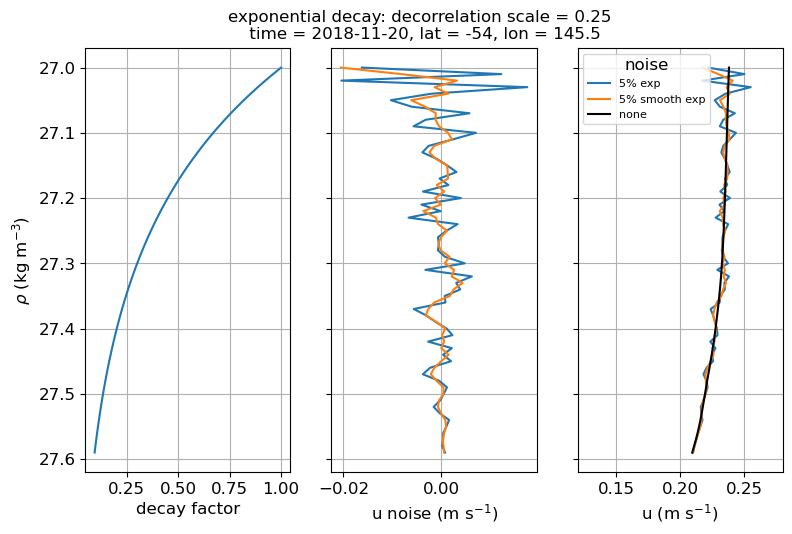

In [159]:
# velocity noise
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey = True, figsize = (9, 5.5))

std_dev_profile.plot(ax = ax1, y = 'density')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('')
ax1.set_xlabel('decay factor')
ax1.set_ylabel(r'$\rho$ (kg m$^{-3}$)')

(noise_sel*std_dev_profile).plot(ax = ax2, y = 'density')
(noise_sel_smooth*std_dev_profile).plot(ax = ax2, y = 'density')
ax2.grid()
ax2.set_ylabel('')
ax2.set_xlabel('u noise (m s$^{-1}$)')
ax2.set_title('')

# velocity signal with and without noise
u_no_noise = satgem_sel.ugw.sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
u_sel = (satgem_sel.ugw + noise_sel*std_dev_profile).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
u_sel_smooth = (satgem_sel.ugw + noise_sel_smooth*std_dev_profile).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')

u_sel.plot(ax = ax3, y = 'density')
u_sel_smooth.plot(ax = ax3, y = 'density')
u_no_noise.plot(ax = ax3, y = 'density', c = 'k')
ax3.set_ylabel('')
ax3.set_xlabel('u (m s$^{-1}$)')
ax3.set_xlim(0.12, 0.28)
ax3.legend(['5% exp', '5% smooth exp', 'none'], title = 'noise', prop={'size': 8}, loc = 'upper left')
ax3.grid()
ax3.set_title('')

plt.suptitle(f'exponential decay: decorrelation scale = {decorrelation_density_scale} \n time = {t}, lat = {lt}, lon = {ln}', fontsize = 12, y = 0.95)

In [124]:
# name = f'SEIR_noise_profile_{pc}noise_exp_smoothed.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [125]:
density_scale = 0.1  # Density scale of perturbation (in kg/m³)
max_perturbation = 0.05  # Maximum perturbation as a percentage of velocity (5%)
central_density = 27.2 

perturbation_profile = np.exp(-((u_sel.density - central_density) ** 2) / (2 * density_scale ** 2)) * max_perturbation

In [126]:
## scale by velocity magnitude
perturb_noise_u = np.zeros(satgem_sel.ugw.shape)*np.nan
perturb_noise_v = np.zeros(satgem_sel.vgw.shape)*np.nan

for d in np.arange(0, len(satgem_sel.density), 2):
    u_abs = np.abs(satgem_sel.ugw[:, d, :, :]) 
    v_abs = np.abs(satgem_sel.vgw[:, d, :, :]) 
    
    density_perturbation_u = np.random.normal(0, perturbation_profile[d]*u_abs, u_abs.shape)
    density_perturbation_v = np.random.normal(0, perturbation_profile[d]*v_abs, v_abs.shape)

    perturb_noise_u[:, d, :, :] = density_perturbation_u
    perturb_noise_v[:, d, :, :] = density_perturbation_v

perturb_noise_u = xr.DataArray(perturb_noise_u, dims = satgem_sel.ugw.dims, coords = satgem_sel.ugw.coords)
perturb_noise_v = xr.DataArray(perturb_noise_v, dims = satgem_sel.vgw.dims, coords = satgem_sel.vgw.coords)

In [127]:
noise_u_sel = perturb_noise_u.sel(time = t, latitude = lt, longitude = ln, method= 'nearest')

Text(0.5, 0.97, 'noise perturbation centered at 27.2 kg m$^{-3}$\n time = 2018-11-20, lat = -54, lon = 145.5')

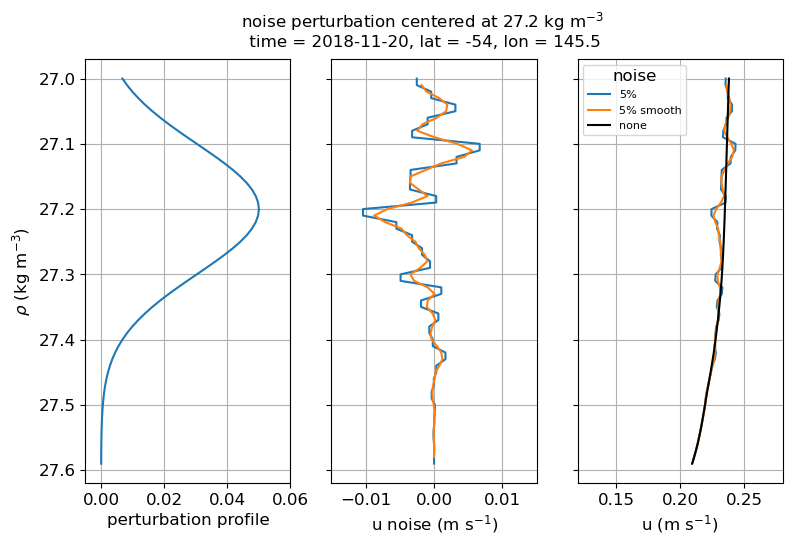

In [308]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey = True, figsize = (9, 5.5))

# perturbation profile
perturbation_profile.plot(ax = ax1, y = 'density')
ax1.invert_yaxis()
ax1.grid()
ax1.set_title('')
ax1.set_xlim(-0.005, 0.06)
ax1.set_xlabel('perturbation profile')
ax1.set_ylabel(r'$\rho$ (kg m$^{-3}$)')

# velocity noise
noise1 = noise_u_sel.interpolate_na(dim = 'density', method = 'nearest', fill_value = 'extrapolate')
noise2 = noise_u_sel.interpolate_na(dim = 'density', method = 'nearest', fill_value = 'extrapolate').rolling(density = 3, center = True).mean()
noise1.plot(ax = ax2, y = 'density')
noise2.plot(ax = ax2, y ='density')
ax2.grid()
ax2.set_ylabel('')
ax2.set_xlim(-0.015, 0.015)
ax2.set_xlabel('u noise (m s$^{-1}$)')
ax2.set_title('')

# velocity signal with and without noise
u_sel = (satgem_sel.ugw + noise1).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')
u_sel_smooth = (satgem_sel.ugw + noise2).sel(time = t, latitude = lt, longitude = ln, method= 'nearest')

u_sel.plot(ax = ax3, y = 'density')
u_sel_smooth.plot(ax = ax3, y = 'density')
u_no_noise.plot(ax = ax3, y = 'density', c = 'k')
ax3.set_ylabel('')
ax3.set_xlabel('u (m s$^{-1}$)')
ax3.set_xlim(0.12, 0.28)
ax3.legend(['5%', '5% smooth', 'none'], title = 'noise', prop={'size': 8}, loc = 'upper left')
ax3.grid()
ax3.set_title('')

plt.suptitle(f'noise perturbation centered at {central_density}' + r' kg m$^{-3}$' + f'\n time = {t}, lat = {lt}, lon = {ln}', fontsize = 12, y = 0.97)

In [309]:
# name = f'SEIR_noise_profile_{pc}noise_perturb_smoothed.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

#### apply noise to all data

In [ ]:
# add the smoothed noise back in
satgem_sel["smooth_noise_u"] = satgem_sel.ugw + smooth_noise_u
satgem_sel["smooth_noise_v"] = satgem_sel.vgw + smooth_noise_v

satgem_sel["smooth_noise_u_exp"] = satgem_sel.ugw + smooth_noise_u*std_dev_profile
satgem_sel["smooth_noise_v_exp"] = satgem_sel.vgw + smooth_noise_v*std_dev_profile

satgem_sel["smooth_noise_u_perturb"] = satgem_sel.ugw + perturb_noise_u
satgem_sel["smooth_noise_v_perturb"] = satgem_sel.vgw + perturb_noise_v

In [ ]:
# satgem_sel.to_netcdf('data/satgem_SEIR_on_d_noise_exp.nc')

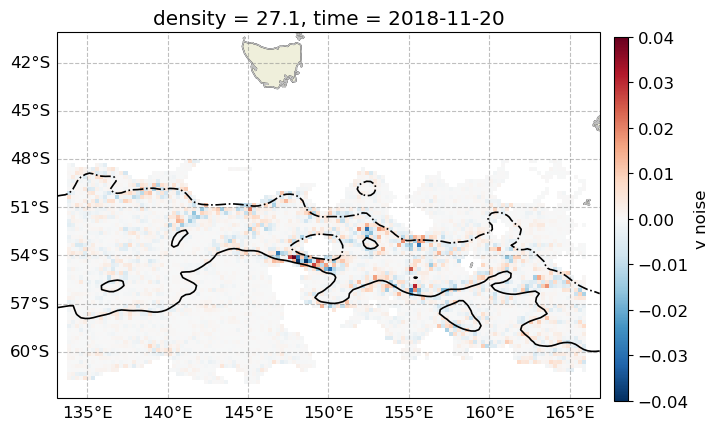

In [121]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im = noise_u.sel(density = 27.1, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                  vmin = -0.04, vmax = 0.04, 
                                                                  transform=ccrs.PlateCarree(), 
                                                                  add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('v noise')

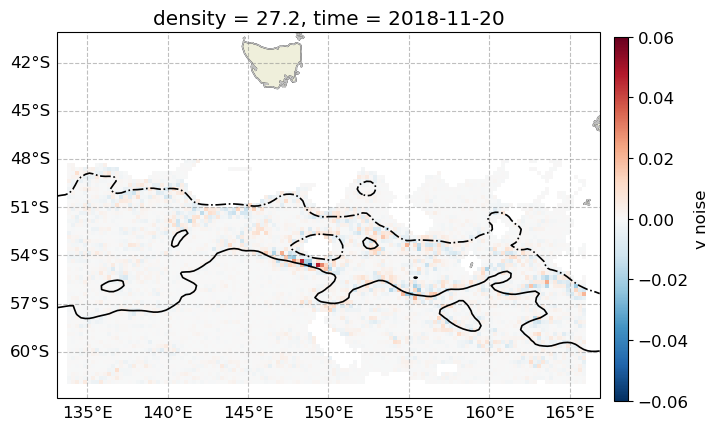

In [105]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im = noise_u.sel(density = 27.2, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                  vmin = -0.06, vmax = 0.06, 
                                                                  transform=ccrs.PlateCarree(), 
                                                                  add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('v noise')

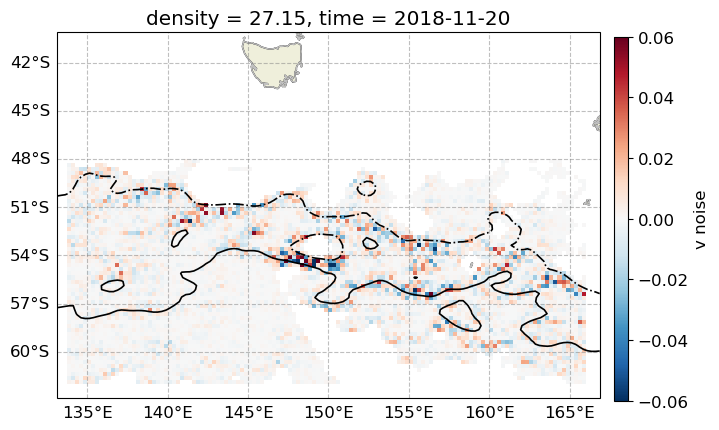

In [108]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im = noise_u.sel(density = 27.15, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                  vmin = -0.06, vmax = 0.06, 
                                                                  transform=ccrs.PlateCarree(), 
                                                                  add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('v noise')

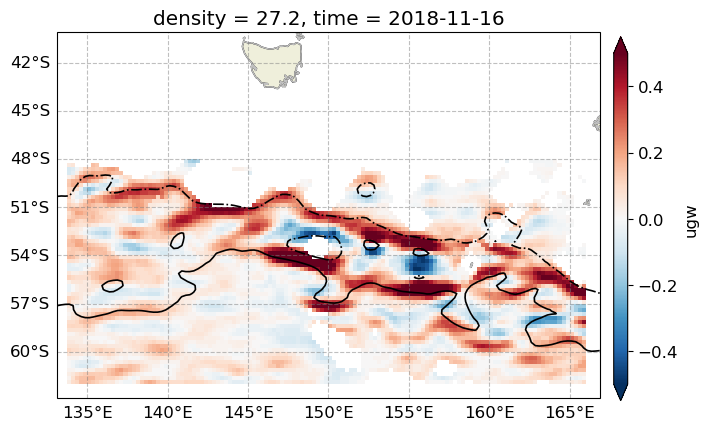

In [12]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
# ax.set_extent([150, 155, -56, -51], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im = satgem_sel.ugw.sel(density = 27.2, time = t, method= 'nearest').plot(cmap = 'RdBu_r',vmin = -0.5, vmax = 0.5, 
                                                          transform=ccrs.PlateCarree(), add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'both')
cb.set_label('ugw')

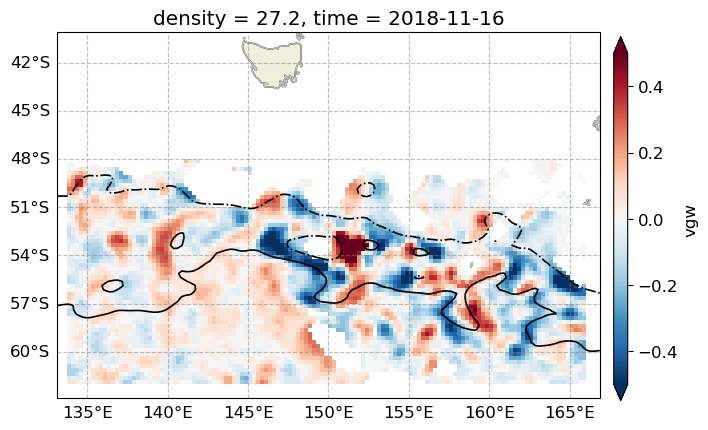

In [13]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
# ax.set_extent([150, 155, -56, -51], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_sel.vgw.sel(density = 27.2, time = t, method= 'nearest').plot(cmap = 'RdBu_r',vmin = -0.5, vmax = 0.5, 
                                                           transform=ccrs.PlateCarree(), add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'both')
cb.set_label('vgw')

Text(0.5, 1.0, '5% noise v: max=-0.19, min=0.18')

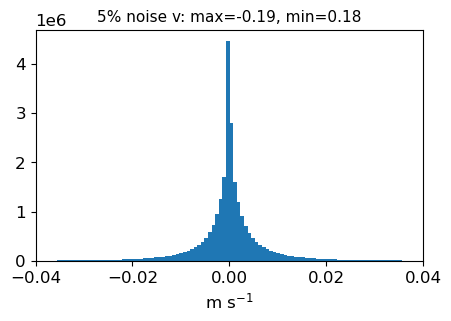

In [25]:
fig, ax = plt.subplots(figsize = (5,3))
plt.hist(noise_v.flatten(), 500)
plt.xlim(-0.04, 0.04)
plt.xlabel('m s$^{-1}$')
plt.title(f'{pc}% noise v: max={np.nanmin(noise_v):.2f}, min={np.nanmax(noise_v):.2f}', fontsize = 11)

Text(0.5, 1.0, '5% noise u: max=-0.20, min=0.20')

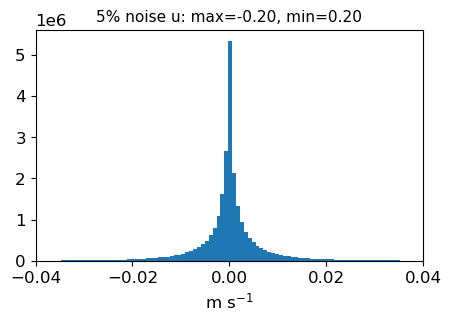

In [26]:
fig, ax = plt.subplots(figsize = (5,3))
plt.hist(noise_u.flatten(), 500)
plt.xlim(-0.04, 0.04)
plt.xlabel('m s$^{-1}$')
plt.title(f'{pc}% noise u: max={np.nanmin(noise_u):.2f}, min={np.nanmax(noise_u):.2f}', fontsize = 11)

In [14]:
satgem_sel['u_noise'] = satgem_sel.ugw + noise_u
satgem_sel['v_noise'] = satgem_sel.vgw + noise_v

In [9]:
# satgem_sel.to_netcdf('satgem_SEIR_on_d_noisy.nc')

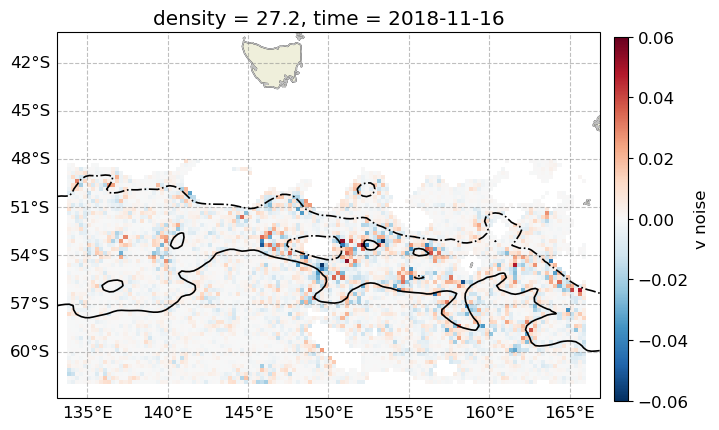

In [28]:
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
# ax.set_extent([150, 155, -56, -51], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  (satgem_sel.vgw - satgem_sel.v_noise).sel(density = 27.2, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                                                  vmin = -0.06, vmax = 0.06, 
                                                                                                  transform=ccrs.PlateCarree(), 
                                                                                                  add_colorbar= False)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('v noise')

#### Add noise in pressure space then convert to density

In [54]:
# satgem_sal_SEIR = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_seir/satGEM_sal_SEIR_2.nc'
# satgem_temp_SEIR = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_seir/satGEM_temp_SEIR_2.nc'
# gw_SEIR_data = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_seir/gw_SEIR_for_maya_2.nc'

In [55]:
# gw_SEIR = xr.open_dataset(gw_SEIR_data).rename({'lat': 'latitude', 'lon':'longitude'})
# satgem_SEIR = xr.open_dataset(satgem_sal_SEIR)
# temp_SEIR = xr.open_dataset(satgem_temp_SEIR)

In [56]:
# satgem_SEIR['temp'] = temp_SEIR.temp
# satgem_SEIR['ugw'] = gw_SEIR.ugw
# satgem_SEIR['vgw'] = gw_SEIR.vgw

In [66]:
# satgem_SEIR.to_netcdf('data/satgem_SEIR_on_p.nc')

In [64]:
satgem_on_p = xr.open_dataset('data/satgem_SEIR_on_p.nc')

In [305]:
def generate_noise_profile(z, fmin, fmax, alpha, intercept, amp_scale=1):
    '''
    z = pressure
    alpha = exponential decay of amplitude with increasing frequency
    intercept = intercept of decay function
    fmin = minimum frequency 
    fmax = maximum frequency
    '''
    num_points = len(z)
    dz = int(np.gradient(z)[0])

    # Step 1: Define the frequency range (0.01 to 0.10 1/m)
    min_freq = 0.01    # Minimum frequency (1/m)
    max_freq = 0.10    # Maximum frequency (1/m)

    # Step 2: Create frequency bins
    frequencies = np.fft.fftfreq(num_points, d=dz)

    # Step 3: Create the Fourier spectrum with random amplitudes and phases
    spectrum = np.zeros(num_points, dtype=complex)
    for i, freq in enumerate(frequencies):
        if min_freq <= abs(freq) <= max_freq:
            amplitude = np.exp(-alpha * abs(freq)) * np.exp(intercept) * amp_scale # Amplitude decays with increasing frequency
            phase = np.random.rand() * 2 * np.pi  # Random phase
            spectrum[i] = amplitude * np.exp(1j * phase)  # Complex number with amplitude and phase

    # Step 4: Generate the profile using the inverse Fourier Transform
    profile = np.fft.ifft(spectrum).real  # Take the real part for the profile
    
    return profile


In [306]:
alpha = 40
intercept = -0.3
fmin = 0.01  
fmax = 0.10
pc = 10

u_sel = satgem_on_p.ugw.sel(latitude = lt, longitude = ln, method = 'nearest')
u_noised = xr.zeros_like(u_sel)*np.nan

z = u_sel.pressure

for prof in range(len(u_sel.time)):
    velocity_amplitude = np.sqrt(np.mean(u_sel[prof]**2)).data
    
    # Generate noise and scale it to match the amplitude of the velocity profile
    noise_profile = generate_noise_profile(z, fmin, fmax, alpha, intercept)
    scaled_noise_profile = noise_profile * (velocity_amplitude*(pc/100) / np.max(np.abs(noise_profile)))

    # Add the scaled noise to the velocity profile
    u_noised[prof] = u_sel[prof] + scaled_noise_profile

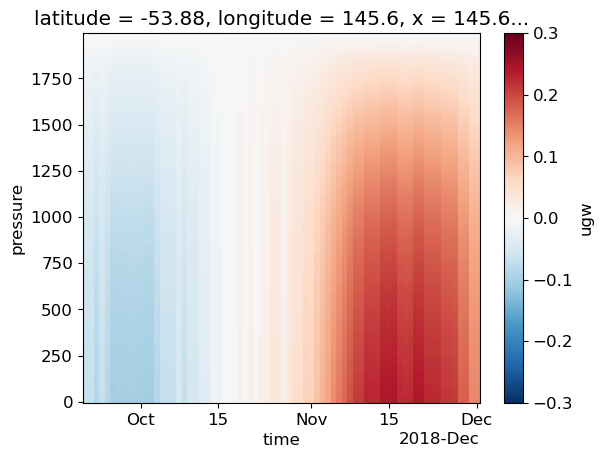

In [307]:
u_sel.plot(x = 'time', vmin = -0.3, vmax = 0.3, cmap = 'RdBu_r')

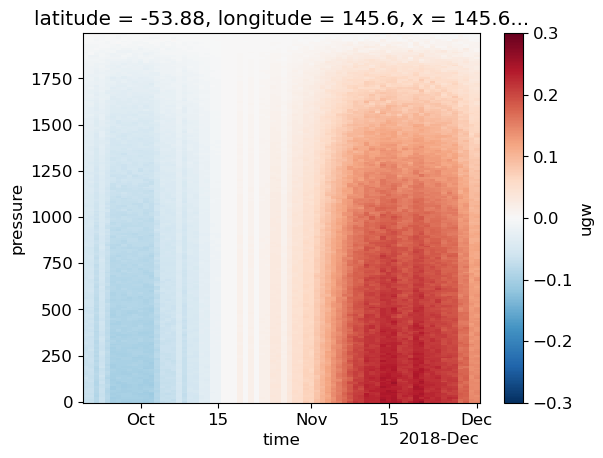

In [308]:
u_noised.plot(x = 'time', vmin = -0.3, vmax = 0.3, cmap = 'RdBu_r')

In [302]:
grid = Grid(satgem_on_p.sel(latitude = lt, longitude = ln, method = 'nearest'), coords={'Z': {'center':'pressure'}}, periodic=False)
dens = gsw.pot_rho_t_exact(satgem_on_p.sal.sel(latitude = lt, longitude = ln, method = 'nearest'), 
                           satgem_on_p.temp.sel(latitude = lt, longitude = ln, method = 'nearest'), 
                           satgem_on_p.pressure, 0) - 1000

u_on_d = grid.transform(u_sel, 'Z', satgem_sel.density.data, target_data=dens).rename({'sal': 'density'})
u_noise_on_d = grid.transform(u_noised, 'Z', satgem_sel.density.data, target_data=dens).rename({'sal': 'density'})

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.01/lib/python3.10/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.01/lib/python3.10/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


Text(0.5, 1.0, '')

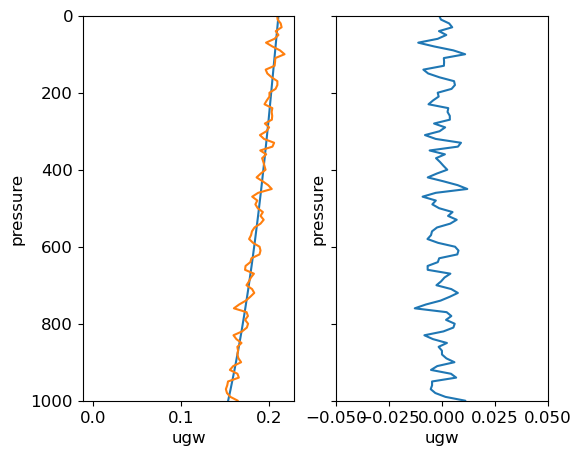

In [309]:
prof = 50
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (6, 5))
u_sel[prof].plot(ax = ax1, y = 'pressure')
u_noised[prof].plot(ax = ax1, y = 'pressure')
ax1.set_ylim(0, 1000)
ax1.invert_yaxis()
ax1.set_title('')
(u_noised[prof] - u_sel[prof]).plot(ax = ax2, y = 'pressure')
ax2.set_xlim(-0.05, 0.05)
ax2.set_title('')

Text(0.5, 1.0, '')

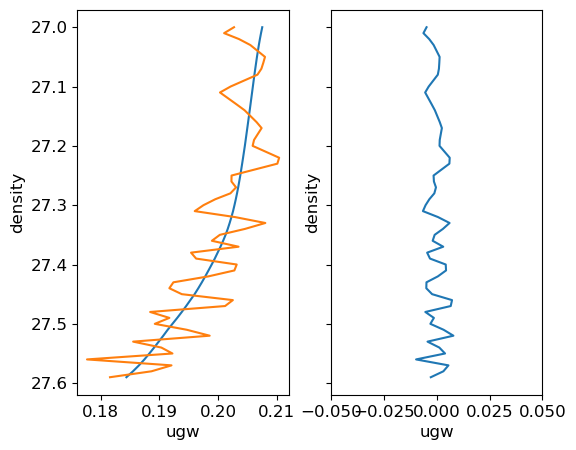

In [304]:
prof = 50
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (6, 5))
u_on_d[prof].plot(ax = ax1, y = 'density')
u_noise_on_d[prof].plot(ax = ax1, y = 'density')
# ax1.set_ylim(0, 1000)
ax1.invert_yaxis()
ax1.set_title('')
(u_noise_on_d[prof] - u_on_d[prof]).plot(ax = ax2, y = 'density')
ax2.set_xlim(-0.05, 0.05)
ax2.set_title('')

Text(0.5, 1.0, '')

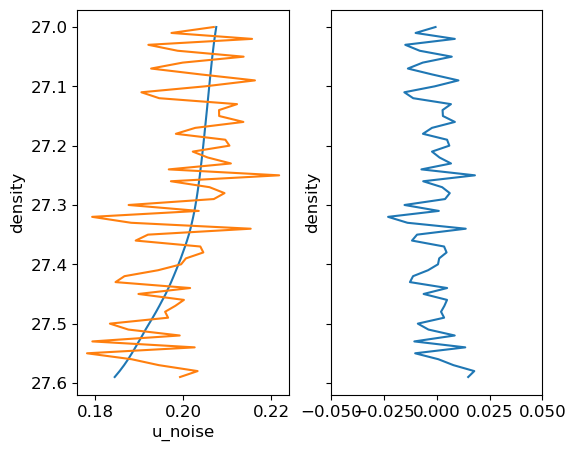

In [180]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (6, 5))
satgem_sel.ugw.sel(latitude = lt, longitude = ln, method = 'nearest')[prof].plot(ax = ax1, y = 'density')
satgem_sel.u_noise.sel(latitude = lt, longitude = ln, method = 'nearest')[prof].plot(ax = ax1, y = 'density')
ax1.invert_yaxis()
ax1.set_title('')
(satgem_sel.u_noise - satgem_sel.ugw).sel(latitude = lt, longitude = ln, method = 'nearest')[prof].plot(ax = ax2, y = 'density')
ax2.set_xlim(-0.05, 0.05)
ax2.set_title('')

#### Add Gaussian noise to velocities on pressure then convert to density

In [203]:
# Gaussian noise scaled by the velocity amplitude (noise increases with velocity amplitude)
mean = 0
pc = 5

scaling_u = (pc/100)*abs(satgem_on_p.ugw)
noise_u = np.random.normal(mean, scale = scaling_u)

scaling_v = (pc/100)*abs(satgem_on_p.vgw)
noise_v = np.random.normal(mean, scale = scaling_v)

noise_u = xr.DataArray(noise_u, dims = satgem_on_p.ugw.dims, coords = satgem_on_p.ugw.coords)
noise_v = xr.DataArray(noise_v, dims = satgem_on_p.vgw.dims, coords = satgem_on_p.vgw.coords)

In [205]:
satgem_on_p['u_noise'] = satgem_on_p.ugw + noise_u
satgem_on_p['v_noise'] = satgem_on_p.vgw + noise_v

In [218]:
# func.satgem_toDens(satgem_on_p, satgem_on_p, data_vars = ['sal', 'temp', 'ugw', 'vgw', 'u_noise', 'v_noise'], save_to = 'satgem_noised_on_d.nc')

### run particle tracking experiments

In [8]:
# Gaussian noise added on density surfaces
satgem_sel = xr.open_dataset('data/satgem_SEIR_on_d_noisy.nc')

## other noise experiments on density
# satgem_sel = xr.open_dataset('data/satgem_SEIR_on_d_noise_exp.nc')

## Gaussian noise added on pressure surfaces
# satgem_sel = xr.open_dataset('data/satgem_noised_on_d.nc').sel(density = slice(27.0, 27.6))

In [14]:
variables = {"U": "ugw", "V": "vgw", "T": "temp", "S": "sal"}
# variables = {"U": "u_noise_2pc", "V": "v_noise_2pc", "T": "temp", "S": "sal"}
# variables = {"U": "u_noise", "V": "v_noise", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u", "V": "smooth_noise_v", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u_exp", "V": "smooth_noise_v_exp", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u_perturb", "V": "smooth_noise_v_perturb", "T": "temp", "S": "sal"}

dimensions = {
    "U": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "V": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "T": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "S": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
}

In [15]:
fieldset = FieldSet.from_xarray_dataset(satgem_sel, variables, dimensions,
                                        interp_method={"U": "partialslip",
                                                       "V": "partialslip",
                                                       "T" : "linear_invdist_land_tracer",
                                                       "S" : "linear_invdist_land_tracer",})

In [16]:
SampleParticle = JITParticle.add_variables(
    ["temp", "sal",
     Variable("U", dtype=np.float32, initial=np.nan),
     Variable("V", dtype=np.float32, initial=np.nan)])

### meridional section of particles

In [9]:
t = '2018-11-20'
# set intial time to seed particles
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

In [10]:
lon0 = 153

In [11]:
y = np.arange(-58, -50.95, 0.1)
x = np.tile(lon0, y.shape)

In [12]:
dens = np.arange(27.1, 27.5, 0.01)

In [13]:
xx = np.repeat(x[:, np.newaxis], len(dens), axis=1)
yy = np.repeat(y[:, np.newaxis], len(dens), axis=1)

In [14]:
dens_2d = np.repeat(dens[np.newaxis, :], xx.shape[0], axis=0)

In [15]:
n_particles = len(xx.flatten())
time = np.tile(satgem_sel.time[t0].data, n_particles)

In [16]:
n_days = 15

lons = xx
lats = yy

In [17]:
pc = 5 # percent noise in velocities
timestep = 6 #hours

In [241]:
# pset = ParticleSet(
#     fieldset=fieldset, pclass=SampleParticle, lon=lons, 
#     lat=lats, time=time, depth = dens_2d
# )

# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_on_p_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_exp_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_perturb_{t}.zarr'

# output_file = pset.ParticleFile(name=filename, outputdt=timedelta(hours=timestep))

# # set dt to negative for backward advection
# dt = -timedelta(hours=timestep)

# pset.execute(
#     [AdvectionRK4, SampleTS, SampleUV, StuckParticles],
#     runtime=timedelta(days=n_days),
#     dt=dt,
#     output_file=output_file,
# )

INFO: Output files are stored in output/SEIR/MeridionalSection_153_15days_5noise_on_p_2018-11-20.zarr.
100%|██████████| 1296000.0/1296000.0 [00:47<00:00, 27356.39it/s]


In [53]:
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_on_p_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_exp_{t}.zarr'
filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_perturb_{t}.zarr'

In [54]:
ds_out = xr.open_zarr(filename)
df = ds_out.to_dataframe()

In [55]:
days = 15
sample_interval = int(24/timestep)
t_ind = days*sample_interval

In [56]:
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-05T00:00:00.000000000 2018-11-20T00:00:00.000000000


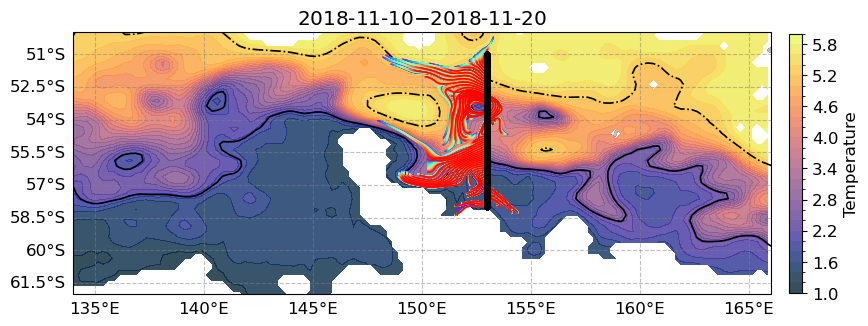

In [30]:
fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -50], crs=ccrs.PlateCarree())

n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

func.map_properties(ax, slice(satgem_SEIR_on_d.time[t0-10], satgem_SEIR_on_d.time[t0]), ssh_insitu)

i = 0
for d in dens:
    df_sel = df.loc[df['z'] == d]
    im = plt.plot(df_sel.to_xarray().lon.T[0:41], df_sel.to_xarray().lat.T[0:41], c = colors[i], alpha = 0.7,
                  linewidth = 0.9, transform=ccrs.PlateCarree(),)
    i +=1

ax.legend_ = None
plt.plot(ds_out.lon[:, 0], ds_out.lat[:, 0], "o", ms = 3, c = 'k', alpha=0.5, transform=ccrs.PlateCarree())

meanT = satgem_SEIR_on_d.temp.sel(time = slice(satgem_SEIR_on_d.time[t0-10], satgem_SEIR_on_d.time[t0])).mean('time')
im = meanT.sel(density = dens[0], method = 'nearest').plot.contourf(cmap = cmocean.cm.thermal, levels = np.arange(1, 6.2, 0.2), 
                                                                            transform=ccrs.PlateCarree(), add_colorbar = False, alpha = 0.8, zorder = 0)


start = str(satgem_SEIR_on_d.time[t0-10].data.astype('M8[D]'))
end = str(satgem_SEIR_on_d.time[t0].data.astype('M8[D]'))
plt.title(start + '$-$' + end)

cbar_ax = fig.add_axes([0.92, 0.31, 0.015, 0.37]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature')

In [57]:
col_idx = np.arange(0, len(ds_out.trajectory), len(dens))
originT, originS = func.origin_TS(ds_out, col_idx, t_ind, dens)

In [58]:
seed_temp = ds_out.temp[:, 0]
seed_sal = ds_out.sal[:, 0]

ti, si, dens_contour = func.tsDensContour(seed_sal, seed_temp)

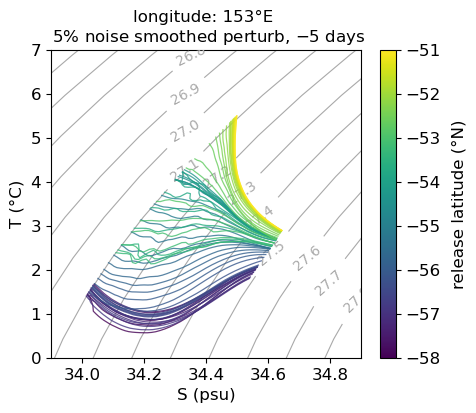

In [279]:
fig, ax = plt.subplots(figsize = (5, 4))

CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

n = len(y)
colors = plt.cm.viridis(np.linspace(0,1,n))

k = 0
for prof in range(len(originS)): 
    im = ax.plot(originS[prof], originT[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    k+=1

# lt = -53.8
# ax.plot(originS.sel(latitude = lt, method = 'nearest'),
#         originT.sel(latitude = lt, method = 'nearest'), 
#         c = 'tab:red', zorder = 100)

plt.xlim(33.9,34.9)
plt.ylim(0, 7)
plt.ylabel('T (°C)')
plt.xlabel('S (psu)')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(y), vmax=max(y)))
cb = plt.colorbar(sm, ax=ax)
cb.set_label(label = 'release latitude (°N)', labelpad = 8)

# plt.title(f'{pc}% noise, $-${days} days')
# plt.title(f'longitude: {lon0}°E \n {pc}% noise, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed exp, $-${days} days', fontsize = 12)
plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed perturb, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E', fontsize = 13)
# plt.title(f'longitude: {lon0}°E, latitude: {lt}°N', fontsize = 12)
plt.show()

In [280]:
# name = f'SEIR_TS_{lon0}_{pc}noise_smoothed_perturb_{days}days.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [59]:
dsc = func.DSC(originT, originS, dens_2d, vert_smooth = False, x_smooth = False)

Text(0.5, 1.0, 'longitude: 153°E \n 5% noise smoothed, $-$15 days')

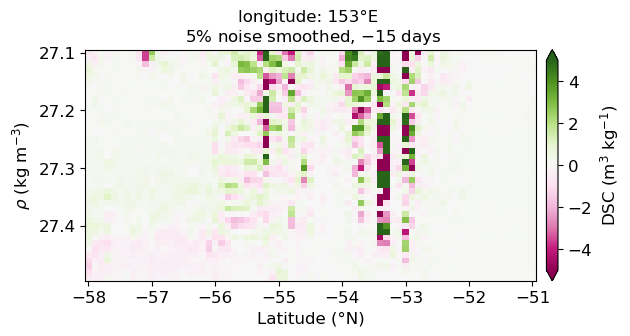

In [25]:
fig, ax = plt.subplots(figsize=(7, 3))
dsc.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, 
         cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))
ax.invert_yaxis()
ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°N)')
# plt.title(f'longitude: {lon0}°E \n {pc}% noise, $-${days} days', fontsize = 12)
plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed exp, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed perturb, $-${days} days', fontsize = 12)

In [307]:
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_{days}days.png'
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_exp_{days}days.png'
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_perturb_{days}days.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

#### Add T gradient contours

In [60]:
t_sel = satgem_sel.temp.sel(time = slice(start, end))
t_grad = func.sshGrad(t_sel)

In [61]:
avg_t_grad = func.col_trajectory_avg(ds_out, t_grad, col_idx, t_ind, dens)
avg_t_grad = xr.DataArray(avg_t_grad, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'longitude: 153°E \n 5% noise smoothed perturb, $-$15 days')

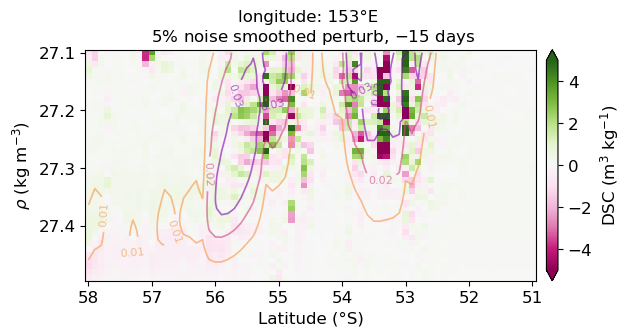

In [62]:
fig, ax = plt.subplots(figsize=(7, 3))
dsc.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, 
         cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

CS = avg_t_grad.plot.contour(x = 'latitude', cmap = 'plasma_r', levels = np.arange(0, 0.05, 0.01), linewidths = 1.2, alpha = 0.6)
plt.clabel(CS, np.arange(0, 0.05, 0.01), fontsize = 8)

ax.invert_yaxis()

ax.set_xticks(np.arange(-58, -50, 1))
ax.set_xticklabels(np.arange(58, 50, -1))

ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°S)')

# plt.title(f'longitude: {lon0}°E \n {pc}% noise, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed exp, $-${days} days', fontsize = 12)
plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed perturb, $-${days} days', fontsize = 12)

In [63]:
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_{days}days_Tgrad.png'
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_exp_{days}days_Tgrad.png'
# name = f'SEIR_DSC_{lon0}_{pc}noise_smoothed_perturb_{days}days_Tgrad.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Individual column

In [70]:
lt = -53
i = np.where(np.round(originS.latitude, 1) == lt)[0][0]

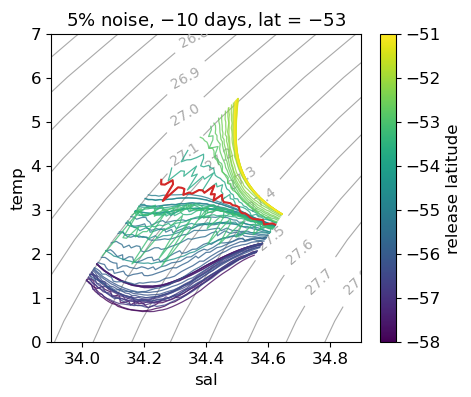

In [71]:
fig, ax = plt.subplots(figsize = (5, 4))

CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

n = len(y)
colors = plt.cm.viridis(np.linspace(0,1,n))

k = 0
for prof in range(len(originS)): 
    im = ax.plot(originS[prof], originT[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    # im = ax.plot(S[prof], T[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    k+=1

ax.plot(originS[i], originT[i], c = 'tab:red', zorder = 100)
# ax.plot(S[i], T[i], c = 'tab:red', zorder = 100)

plt.xlim(33.9,34.9)
plt.ylim(0, 7)
plt.ylabel('temp')
plt.xlabel('sal')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(y), vmax=max(y)))
plt.colorbar(sm, ax=ax, label = 'release latitude')

plt.title(f'{pc}% noise, $-${day}, lat = ${lt}$', fontsize = 13)
plt.show()

In [72]:
i = np.where(ds_out.lat[:, 0] == lt)[0][0]

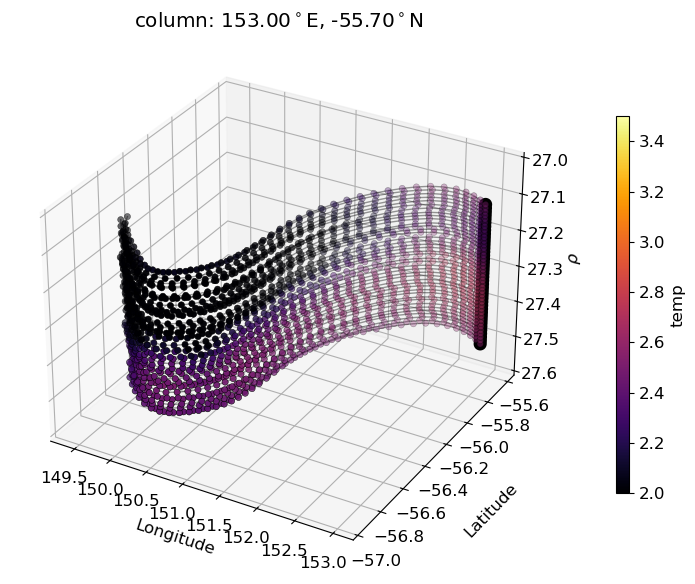

In [175]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='3d')

for d in range(i, i+len(dens)):
    ax.plot(ds_out.lon[d, :t+1].T, ds_out.lat[d, :t+1].T, zs = ds_out.z[d, :t+1].T, c = 'k', linewidth = 1, alpha = 0.4)
    
    im = ax.scatter(ds_out.lon[d, :t+1].T, ds_out.lat[d, :t+1].T, zs = ds_out.z[d, :t+1].T, c = ds_out.temp[d, :t+1].T, cmap=plt.cm.inferno, 
               norm=mpl.colors.Normalize(vmin=2, vmax=3.5),edgecolor="k", zorder=2, linewidth = 0.4, s=20)
    
    ax.scatter(ds_out.lon[d, 0], ds_out.lat[d, 0], zs = ds_out.z[d, 0], facecolors = 'none', 
               linewidth = 5, edgecolor = 'k', s=20, zorder = np.inf)
    
ax.set_zlim(27, 27.6)
ax.invert_zaxis()
# ax.set_xlim(149, 155)
# ax.set_ylim(-56, -52)
# ax.set_yticks(np.arange(-52.5, -50, 0.5))

ax.set_ylabel('Latitude', labelpad = 15)
ax.set_xlabel('Longitude')
ax.set_zlabel(r'$\rho$')

plt.colorbar(im, label="temp", aspect = 30, shrink = 0.7, pad = 0.07)
plt.title(f'column: {ds_out.lon[i, 0].values:.2f}$^\circ$E, {ds_out.lat[i, 0].values:.2f}$^\circ$N')
ax.view_init(elev=30, azim=-60)
plt.tight_layout()

In [46]:
times = xr.DataArray(ds_out.time[0, :t+1].values, dims = ['time'], 
                     coords = dict(time = ('time', ds_out.time[0, :t+1].values)))

In [47]:
sample_interval = 4 # per day

In [132]:
time = '2018-11-07'
day_ind = np.where(times == times.sel(time = time, method = 'nearest'))[0][0]
print(f'day = {-day_ind/sample_interval}')
print(times[day_ind].values)
extent = [149, 155, -57, -52]
# extent = [149, 155, -56, -51]
# extent = [149, 155, -58, -53]

# time index
t1 = np.where(satgem_sel.time == satgem_sel.time.sel(time = time, method = 'nearest'))[0][0]
d = 27.2

day = 0.0
2018-10-30T00:00:00.000000000


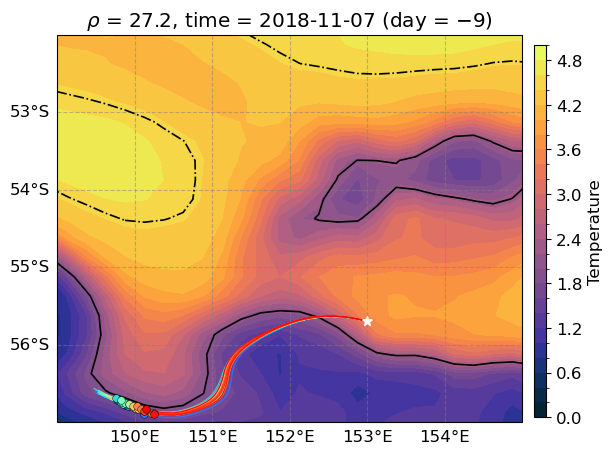

In [179]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = satgem_sel.temp[t1].sel(density = d, method = 'nearest').plot.contourf(cmap = cmocean.cm.thermal, levels = np.arange(0, 5.2, 0.2), 
                                                                        transform=ccrs.PlateCarree(), add_colorbar = False)
func.map_properties(ax, t1, ssh_insitu, contours = True)

# particle release location
plt.scatter(ds_out.lon[i, 0].values, ds_out.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 50) 

# particle trajectories
n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

j = 0
for rho in range(i, i+len(dens)):
    lon = ds_out.lon[rho, day_ind]
    lat = ds_out.lat[rho, day_ind]
    plt.plot(ds_out.lon[rho,:t], ds_out.lat[rho, :t], color = colors[j], transform=ccrs.PlateCarree(), linewidth = 0.8)
    plt.scatter(lon, lat, color = colors[j], edgecolors = 'k', s = 30, linewidths = 0.3, transform=ccrs.PlateCarree(), zorder = 50)
    j+=1

plt.title(r'$\rho$' f' = {d}, time = {time} (day = $-${int(day_ind/sample_interval)})')

cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.62]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature')

### change in ADT

In [140]:
lons = ds_out.lon[i:i+len(dens), :t+1]
lats = ds_out.lat[i:i+len(dens), :t+1]

In [141]:
shp = (len(times), len(dens))
arr = np.ma.masked_all(shp).data*np.nan

In [182]:
adt_sel = xr.DataArray(arr.copy(), dims = ['time', 'potential_density'])

for it in range(len(times)):
    adt_interp = []
    for d in range(0, len(dens)):
        adt_interp.append(ssh_insitu.adt.interp(time = times[it], longitude = lons[d, it], latitude = lats[d, it]).data)
    
    adt_sel[it] = np.asarray(adt_interp)

In [183]:
adt_sel['time'] = times
adt_sel['potential_density'] = dens

Text(0, 0.5, '$\\rho$')

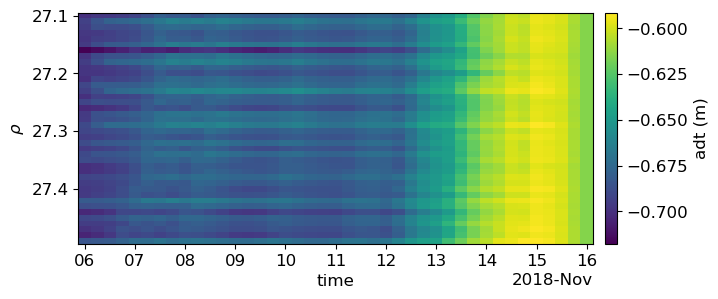

In [184]:
fig, ax = plt.subplots(figsize = (8,3))
adt_sel.plot(x = 'time', cbar_kwargs = dict(label = u'adt (m)', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### change in temp

In [185]:
T = xr.DataArray(arr.copy(), dims = ['time', 'potential_density'])
S = xr.DataArray(arr.copy(), dims = ['time', 'potential_density'])

j = 0
for d in range(i, i+len(dens)):
    T[:,j] = ds_out.temp[d, :t+1].T.values
    S[:,j] = ds_out.sal[d, :t+1].T.values
    j+=1

T = T.assign_coords({'potential_density': dens, 'time': times.values})
S = S.assign_coords({'potential_density': dens, 'time': times.values})

Text(0, 0.5, '$\\rho$')

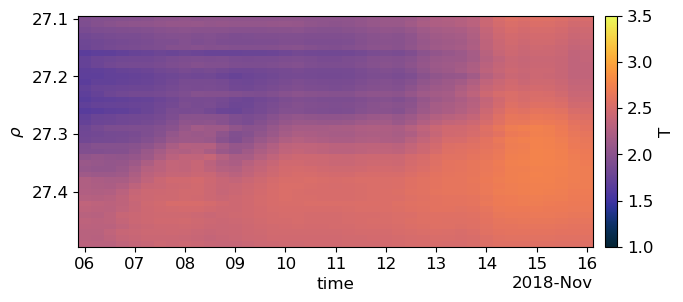

In [216]:
fig, ax = plt.subplots(figsize = (8, 3))
T.plot(x = 'time', cmap = cmocean.cm.thermal, vmin = 1, vmax = 3.5, cbar_kwargs = dict(label = 'T', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### DSC along trajectory

In [187]:
dens_2d = np.repeat(dens[np.newaxis, :], times.shape, axis=0)

In [188]:
col_dsc = func.DSC(T, S, dens_2d, vert_smooth = False, x_smooth = False)

Text(0.5, 1.0, 'column: 153.00$^\\circ$E, -55.70$^\\circ$N')

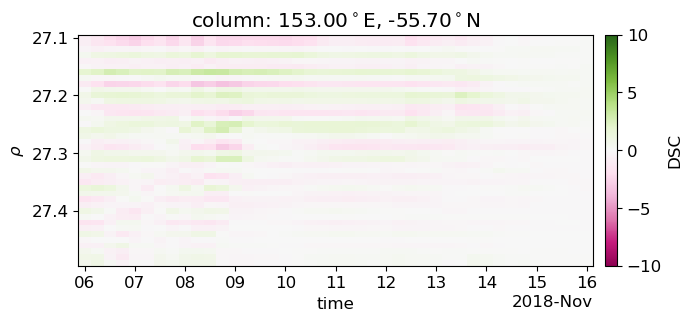

In [189]:
fig, ax = plt.subplots(figsize = (8, 3))
col_dsc.plot(x = 'time', cmap = 'PiYG', vmin = -10, vmax = 10, cbar_kwargs = dict(label = 'DSC', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')
# ax.set_xticks(times[0:-1:2*sample_interval], labels = -np.arange(0, 10, 2))
# ax.set_xlabel('time (days)') 
plt.title(f'column: {ds_out.lon[i, 0].values:.2f}$^\circ$E, {ds_out.lat[i, 0].values:.2f}$^\circ$N')

### particle dispersion

In [190]:
shp = lons.values.shape
cum_dist = np.ma.masked_all(shp).data*np.nan

for d in range(len(dens)):
    dist_diff = np.concatenate((np.array([0]), gsw.distance(lons[d].values, lats[d].values)))
    dist_diff_km = dist_diff/1000
    dist_from_start = np.nancumsum(dist_diff_km)
    cum_dist[d] = dist_from_start

In [191]:
var_dist = []
var_dist_rolling = xr.DataArray(np.arange(len(times)*len(dens)).reshape(len(times), len(dens)), dims = ['time', 'density'])*np.nan

for it in range(len(times)):
    N = len(cum_dist[:, it])
    mean_dist = np.nanmean(cum_dist[:, it])
    diff_dist = cum_dist[:, it] - mean_dist
    var_dist.append(np.nanmean(diff_dist**2))

    dist_da = xr.DataArray(cum_dist[:, it], dims = ['density'])
    mean_dist_rolling = dist_da.rolling(density = 5, center = True, min_periods = 3).mean()
    diff_dist_rolling = dist_da - mean_dist_rolling
    var_dist_rolling[it] = diff_dist_rolling**2

In [192]:
dist_dispersion = xr.DataArray(var_dist, dims = ['time'], coords = dict(time = ('time', times.values)))
var_dist_rolling = var_dist_rolling.assign_coords(time = ('time', times.data), density = ('density', dens))

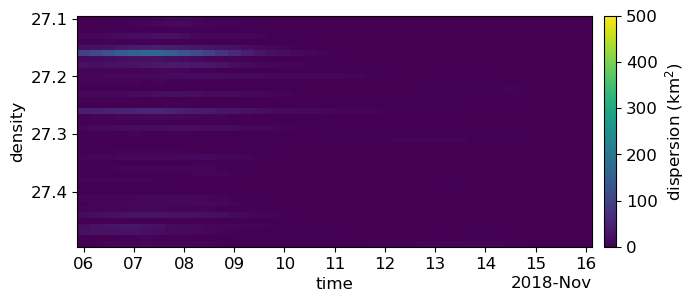

In [193]:
fig, ax = plt.subplots(figsize = (8,3))
var_dist_rolling.plot(x = 'time', vmin = 0, vmax = 500, cbar_kwargs = dict(label = u'dispersion (km$^{2}$)', pad = 0.02))
ax.invert_yaxis()

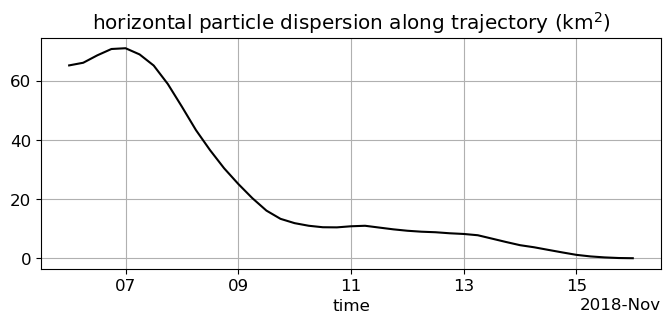

In [194]:
fig, ax = plt.subplots(figsize = (8, 3))
dist_dispersion.plot(c = 'k')
plt.title('horizontal particle dispersion along trajectory (km$^{2}$)')
plt.grid()

### Temperature standard deviation in each grid box duirng the advection time

In [133]:
day_sel = day.astype(np.int64)
print(f'-{day}')
start = satgem_sel.time[t0-day_sel].data
end = satgem_sel.time[t0].data
print(start, end)

d = 27.2

-10 days
2018-10-20T00:00:00.000000000 2018-10-30T00:00:00.000000000


In [57]:
time = '2018-11-08'
day_ind = np.where(times == times.sel(time = time, method = 'nearest'))[0][0]
print(f'day = {-day_ind/sample_interval}')
print(times[day_ind].values)

day = -10.0
2018-11-20T00:00:00.000000000


In [134]:
t_sel = satgem_sel.temp.sel(time = slice(start, end))
t_std = t_sel.std(dim = 'time')

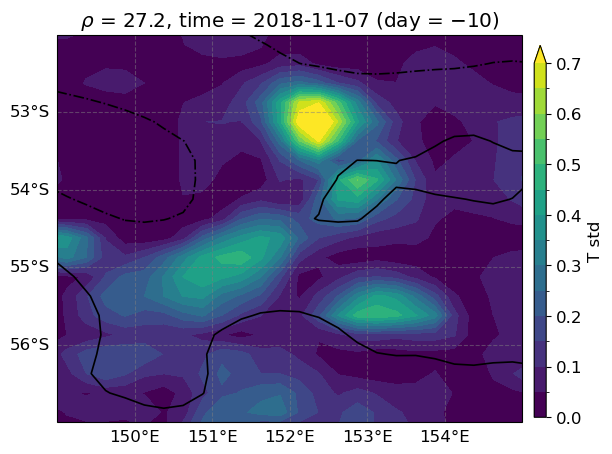

In [63]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = t_std.sel(density = d, method = 'nearest').plot.contourf(cmap = 'viridis', levels = np.arange(0, 0.75, 0.05), 
                         transform=ccrs.PlateCarree(), add_colorbar = False)

func.map_properties(ax, time, ssh_insitu, contours = True)

# particle release location
plt.scatter(ds_out.lon[i, 0].values, ds_out.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 50) 

# particle trajectories
n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

j = 0
for rho in range(i, i+len(dens)):
    lon = ds_out.lon[rho, day_ind]
    lat = ds_out.lat[rho, day_ind]
    plt.plot(ds_out.lon[rho,:t+1], ds_out.lat[rho, :t+1], color = colors[j], transform=ccrs.PlateCarree(), linewidth = 0.8)
    plt.scatter(lon, lat, color = colors[j], edgecolors = 'k', s = 30, linewidths = 0.3, transform=ccrs.PlateCarree(), zorder = 50)
    j+=1

plt.title(r'$\rho$' f' = {d}, time = {time} (day = $-${int(day_ind/sample_interval)})')

cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.62]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('T std')

### Temperature gradient

In [135]:
t_grad = func.sshGrad(t_sel)

In [61]:
t_grad_col = func.col_timeseries(ds_out, t_grad, i, t, dens)

Text(0, 0.5, '$\\rho$')

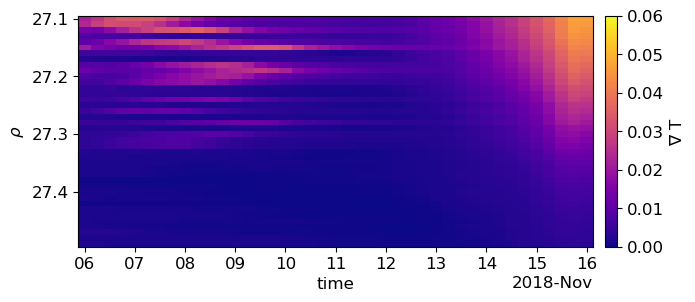

In [92]:
fig, ax = plt.subplots(figsize = (8, 3))
t_grad_col.plot(x = 'time', cmap = 'plasma', vmin = 0, vmax = 0.06, cbar_kwargs = dict(label = r'$\nabla$ T', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### EKE

In [136]:
u = satgem_sel.u_noise.sel(time = slice(start, end))
v = satgem_sel.v_noise.sel(time = slice(start, end))

eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

d = 27.2

mean u and v between 2018-10-20 and 2018-10-30


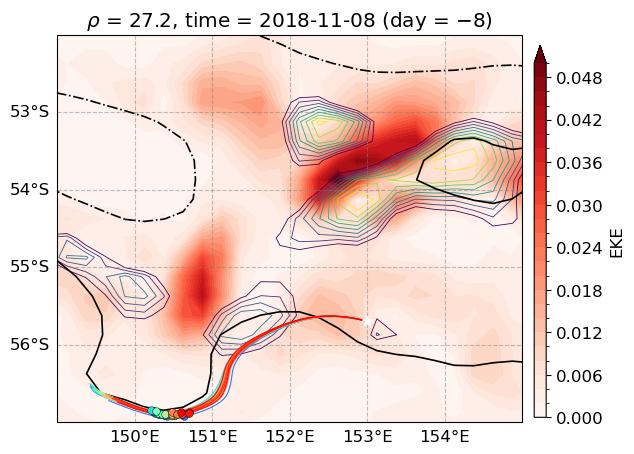

In [203]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# im = eke.sel(time = time, density = d, method = 'nearest').plot.contourf(levels = np.arange(0, 0.052, 0.002), cmap = 'Reds',
#                          transform=ccrs.PlateCarree(), add_colorbar = False)

im = eke.mean(dim = 'time').sel(density = d, method = 'nearest').plot.contourf(levels = np.arange(0, 0.052, 0.002), cmap = 'Reds',
                         transform=ccrs.PlateCarree(), add_colorbar = False)

t_std.sel(density = d, method = 'nearest').plot.contour(cmap = 'viridis', levels = np.arange(0.35, 0.8, 0.05), linewidths = 0.6,
                         transform=ccrs.PlateCarree(), add_colorbar = False)

func.map_properties(ax, time, ssh_insitu, contours = True)

# particle release location
plt.scatter(ds_out.lon[i, 0].values, ds_out.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 50) 

# particle trajectories
n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

j = 0
for rho in range(i, i+len(dens)):
    lon = ds_out.lon[rho, day_ind]
    lat = ds_out.lat[rho, day_ind]
    plt.plot(ds_out.lon[rho,:t+1], ds_out.lat[rho, :t+1], color = colors[j], transform=ccrs.PlateCarree(), linewidth = 0.8)
    plt.scatter(lon, lat, color = colors[j], edgecolors = 'k', s = 30, linewidths = 0.3, transform=ccrs.PlateCarree(), zorder = 50)
    j+=1

plt.title(r'$\rho$' f' = {d}, time = {time} (day = $-${int(day_ind/sample_interval)})')

cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.62]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('EKE')

In [95]:
eke_col = func.col_timeseries(ds_out, eke, i, t, dens)

Text(0, 0.5, '$\\rho$')

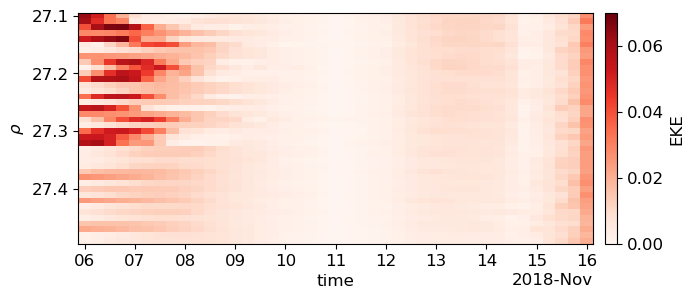

In [96]:
fig, ax = plt.subplots(figsize = (8, 3))
eke_col.plot(x = 'time', cmap = 'Reds', vmin = 0, vmax = 0.07, cbar_kwargs = dict(label = 'EKE', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### Okubo-Weiss

In [97]:
u = satgem_sel.u_noise
v = satgem_sel.v_noise

In [98]:
ow = func.okubo_weiss(u, v)

In [208]:
time = '2018-11-08'
day_ind = np.where(times == times.sel(time = time, method = 'nearest'))[0][0]
print(f'day = {-day_ind/sample_interval}')
print(times[day_ind].values)

d = 27.2

day = -8.0
2018-11-08T00:00:00.000000000


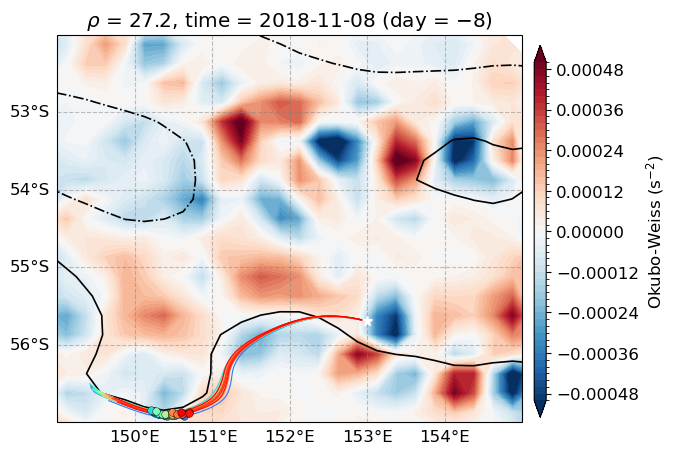

In [209]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = ow.sel(time = time, density = d, method = 'nearest').plot.contourf(cmap = 'RdBu_r', levels = np.arange(-5e-4, 5.2e-4, 2e-5), #levels = np.arange(-8e-4, 8.4e-4, 4e-5), 
                      transform=ccrs.PlateCarree(), add_colorbar = False)

# im = ow.mean(dim = 'time').sel(density = d, method = 'nearest').plot.contourf(cmap = 'RdBu_r', levels = np.arange(-5e-4, 5.2e-4, 2e-5), #levels = np.arange(-8e-4, 8.4e-4, 4e-5), 
#                       transform=ccrs.PlateCarree(), add_colorbar = False)

func.map_properties(ax, time, ssh_insitu, contours = True)

# particle release location
plt.scatter(ds_out.lon[i, 0].values, ds_out.lat[i, 0].values, marker = '*', color = 'w', s = 50, zorder = 50) 

# particle trajectories
n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

j = 0
for rho in range(i, i+len(dens)):
    lon = ds_out.lon[rho, day_ind]
    lat = ds_out.lat[rho, day_ind]
    plt.plot(ds_out.lon[rho,:t+1], ds_out.lat[rho, :t+1], color = colors[j], transform=ccrs.PlateCarree(), linewidth = 0.8)
    plt.scatter(lon, lat, color = colors[j], edgecolors = 'k', s = 30, linewidths = 0.3, transform=ccrs.PlateCarree(), zorder = 50)
    j+=1

plt.title(r'$\rho$' f' = {d}, time = {time} (day = $-${int(day_ind/sample_interval)})')

cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.62]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Okubo-Weiss (s$^{-2}$)')

In [99]:
ow_col = func.col_timeseries(ds_out, ow, i, t, dens)

Text(0, 0.5, '$\\rho$')

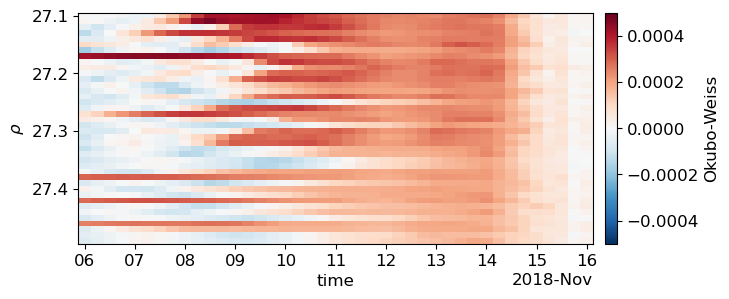

In [100]:
fig, ax = plt.subplots(figsize = (8, 3))
ow_col.plot(x = 'time', cmap = 'RdBu_r', vmin = -5e-4, vmax = 5e-4, cbar_kwargs = dict(label = 'Okubo-Weiss', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### FTLEs

In [153]:
ftle_file = '/g/data/v45/mj0995/fsle/forward_FTLE_seir_10days.nc'
ftle_fw = xr.open_dataset(ftle_file).rename({"lat":"latitude", "lon":"longitude"}).lambda1

In [154]:
ftle_fw_col = func.col_timeseries(ds_out, ftle_fw, i, t, dens)

Text(0, 0.5, '$\\rho$')

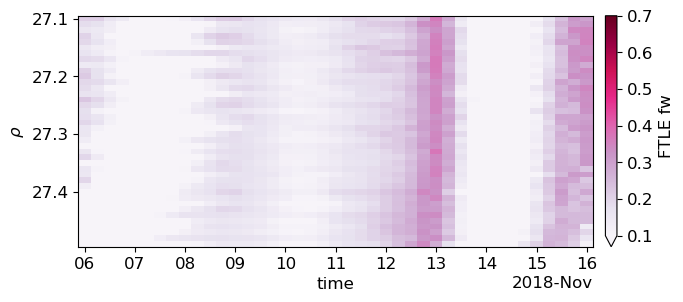

In [155]:
fig, ax = plt.subplots(figsize = (8, 3))
ftle_fw_col.plot(x = 'time', cmap = 'PuRd', vmin = 0.1, vmax = 0.7, cbar_kwargs = dict(label = 'FTLE fw', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

In [ ]:
ftle_file = '/g/data/v45/mj0995/fsle/backward_FTLE_seir_10days.nc'
ftle_bw = xr.open_dataset(ftle_file).rename({"lat":"latitude", "lon":"longitude"}).lambda1

In [ ]:
ftle_bw_col = func.col_timeseries(ds_out, ftle_bw, i, t, dens)

Text(0, 0.5, '$\\rho$')

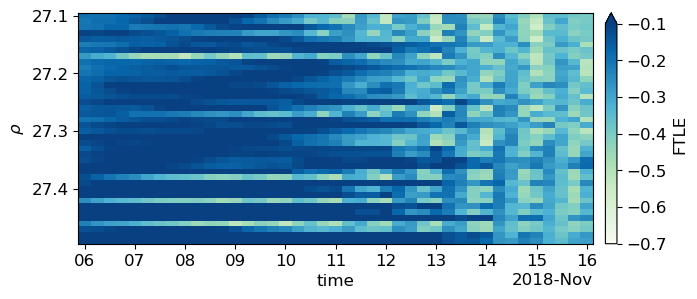

In [60]:
fig, ax = plt.subplots(figsize = (8, 3))
ftle_bw_col.plot(x = 'time', cmap = 'GnBu', vmin = -0.7, vmax = -0.1, cbar_kwargs = dict(label = 'FTLE', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### Gaussian noise experienced by particles

In [257]:
u_noise = satgem_sel.ugw - satgem_sel.u_noise
v_noise = satgem_sel.vgw - satgem_sel.v_noise

In [258]:
u_noise_col = func.col_timeseries(ds_out, u_noise, i, t, dens)
v_noise_col = func.col_timeseries(ds_out, v_noise, i, t, dens)

Text(0, 0.5, '$\\rho$')

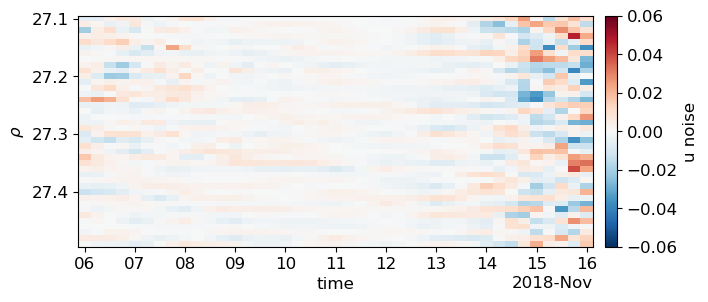

In [259]:
fig, ax = plt.subplots(figsize = (8, 3))
u_noise_col.plot(x = 'time', cmap = 'RdBu_r', vmin = -0.06, vmax = 0.06, cbar_kwargs = dict(label = 'u noise', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

Text(0, 0.5, '$\\rho$')

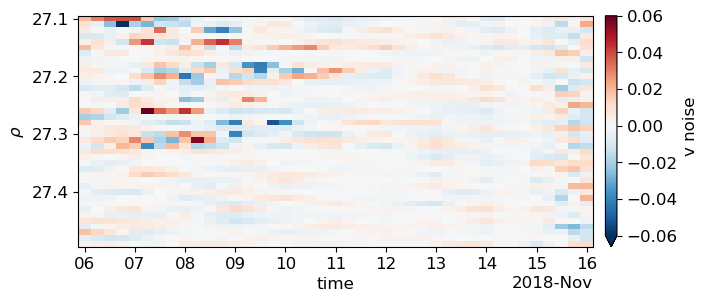

In [260]:
fig, ax = plt.subplots(figsize = (8, 3))
v_noise_col.plot(x = 'time', cmap = 'RdBu_r', vmin = -0.06, vmax = 0.06, cbar_kwargs = dict(label = 'v noise', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$')

### For all trajectory columns, calculate the rate of DSC generation

In [177]:
dsc_generation = func.rate_of_dsc_generation(ds_out, i, t, dens)

Text(0.5, 1.0, 'column: 153.00$^\\circ$E, -53.00$^\\circ$N')

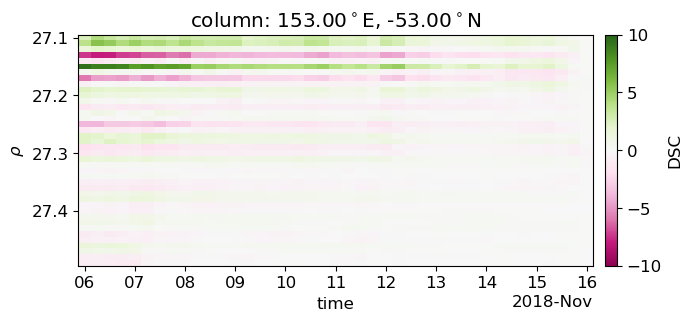

In [74]:
fig, ax = plt.subplots(figsize = (8, 3))
col_dsc.plot(x = 'time', cmap = 'PiYG', vmin = -10, vmax = 10, cbar_kwargs = dict(label = 'DSC', pad = 0.02))
ax.invert_yaxis()
plt.ylabel(r'$\rho$') 
plt.title(f'column: {ds_out.lon[i, 0].values:.2f}$^\circ$E, {ds_out.lat[i, 0].values:.2f}$^\circ$N')

In [249]:
t_ind = 40
origin_temp = ds_out.temp[:, t_ind]
col_idx = np.arange(0, len(origin_temp), len(dens))

In [250]:
dsc_gen = func.all_cols_dsc_generation(ds_out, col_idx, t_ind, dens)
dsc_gen = xr.DataArray(dsc_gen, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'Days for depth-avg DSC magnitude to reach > 1 m^3/kg')

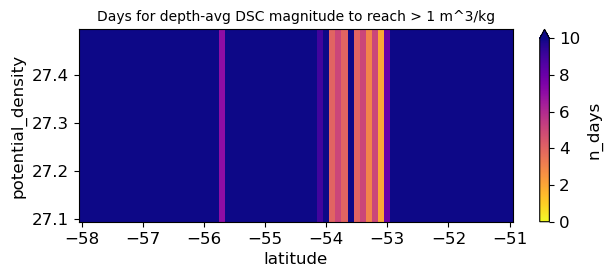

In [252]:
fig, ax = plt.subplots(figsize=(7, 2.5))
dsc_gen.plot(x = 'latitude', cmap = 'plasma_r', vmin = 0, vmax = 10, 
            cbar_kwargs = dict(label = 'n_days'))

plt.title('Days for depth-avg DSC magnitude to reach > 1 m^3/kg', fontsize = 10)